the Training Accuracy (from the last epoch shown in the plot) is approximately 0.9973 and the Test Accuracy is 97.38%

Hybrid 1 Architecture

SMS

 ↓

Token IDs

 ↓

Token Embedding

 ↓

LSTM

 ↓

GRU

 ↓

Dropout

 ↓

Dense

 ↓

Sigmoid

 ↓

HAM / SPAM

In [ ]:
# TensorFlow and basic libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
import os

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

# TensorFlow / Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
print("GPU Available:")

print(
    tf.config.list_physical_devices("GPU")
)

GPU Available:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
data=pd.read_csv('/content/spam.csv', encoding='latin1')

In [ ]:
data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
data.columns = ['label', 'message']

In [ ]:
label_counts = data["label"].value_counts()

print(label_counts)

label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
label_percentage = (
    data["label"]
    .value_counts(normalize=True)
    * 100
)

print(
    label_percentage.round(2)
)

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [ ]:
data["label_num"] = data["label"].map({
    "ham": 0,
    "spam": 1
})

data.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [ ]:
data[
    ["label", "message"]
].sample(
    10,
    random_state=42
)

,label,message
3245,ham,"Funny fact Nobody teaches volcanoes 2 erupt, t..."
944,ham,I sent my scores to sophas and i had to do sec...
1044,spam,We know someone who you know that fancies you....
2484,ham,Only if you promise your getting out as SOON a...
812,spam,Congratulations ur awarded either å£500 of CD ...
2973,ham,"I'll text carlos and let you know, hang on"
2991,ham,K.i did't see you.:)k:)where are you now?
2942,ham,No message..no responce..what happend?
230,ham,Get down in gandhipuram and walk to cross cut ...
1181,ham,You flippin your shit yet?


In [ ]:
print(data.isnull().sum())

label        0
message      0
label_num    0
dtype: int64


In [ ]:
data = data.dropna(
    subset=["message", "label_num"]
).reset_index(drop=True)

print("Dataset size:", len(data))

Dataset size: 5572


In [ ]:
data["char_length"] = data["message"].apply(
    len
)

print(
    "Minimum SMS length:",
    data["char_length"].min()
)

print(
    "Maximum SMS length:",
    data["char_length"].max()
)

print(
    "Average SMS length:",
    data["char_length"].mean()
)

Minimum SMS length: 2
Maximum SMS length: 910
Average SMS length: 80.11880832735105


In [ ]:
data["word_count"] = data["message"].apply(
    lambda x: len(x.split())
)

print(
    "Average number of words per SMS:",
    data["word_count"].mean()
)

Average number of words per SMS: 15.494436468054559


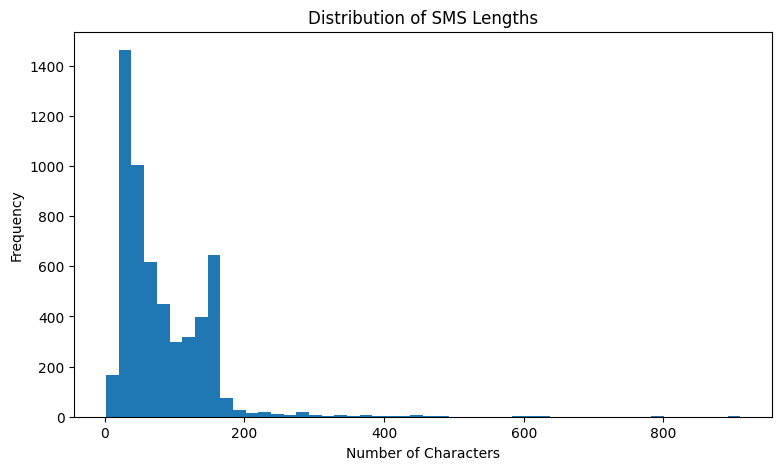

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    data["char_length"],
    bins=50
)

plt.title("Distribution of SMS Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [ ]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove unnecessary extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [ ]:
data["clean_message"] = data["message"].apply(
    clean_text
)

data[
    ["message", "clean_message"]
].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it's been 3 week's n...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me. ...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request 'melle melle (oru minnamin...
8,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more? u r entitle...


In [ ]:
print(
    "Duplicate messages:",
    data["clean_message"].duplicated().sum()
)

Duplicate messages: 415


In [ ]:
data = data.drop_duplicates(
    subset=["clean_message"]
).reset_index(drop=True)

print(
    "Dataset size after duplicate removal:",
    len(data)
)

Dataset size after duplicate removal: 5157


In [ ]:
X = data["clean_message"].values
y = data["label_num"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5157,)
y shape: (5157,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 4125
Testing samples: 1032


In [ ]:
print("Training distribution:")
print(
    pd.Series(y_train).value_counts()
)

print("\nTesting distribution:")
print(
    pd.Series(y_test).value_counts()
)

Training distribution:
0    3611
1     514
Name: count, dtype: int64

Testing distribution:
0    904
1    128
Name: count, dtype: int64


In [ ]:
VOCAB_SIZE = 5000
MAX_LEN = 50

print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Sequence Length:", MAX_LEN)

Vocabulary Size: 5000
Maximum Sequence Length: 50


In [ ]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print(
    "Total words found:",
    len(tokenizer.word_index)
)

Total words found: 7830


In [ ]:
X_train_sequences = tokenizer.texts_to_sequences(
    X_train
)

X_test_sequences = tokenizer.texts_to_sequences(
    X_test
)

print("Original SMS:")
print(X_train[0])

print("\nToken IDs:")
print(X_train_sequences[0])

Original SMS:
haha okay... today weekend leh...

Token IDs:
[213, 385, 89, 352, 386]


In [ ]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(
    "Training shape:",
    X_train_padded.shape
)

print(
    "Testing shape:",
    X_test_padded.shape
)

Training shape: (4125, 50)
Testing shape: (1032, 50)


In [ ]:
sample_index = 0

print("ORIGINAL SMS")
print(X_train[sample_index])

print("\nTOKENS")
print(
    tokenizer.sequences_to_texts(
        [X_train_sequences[sample_index]]
    )[0]
)

print("\nTOKEN IDs")
print(X_train_sequences[sample_index])

print("\nPADDED SEQUENCE")
print(X_train_padded[sample_index])

ORIGINAL SMS
haha okay... today weekend leh...

TOKENS
haha okay today weekend leh

TOKEN IDs
[213, 385, 89, 352, 386]

PADDED SEQUENCE
[213 385  89 352 386   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [ ]:
print(
    "Label:",
    y_train[sample_index]
)

if y_train[sample_index] == 0:
    print("Class: HAM")
else:
    print("Class: SPAM")

Label: 0
Class: HAM


In [ ]:
EMBED_DIM = 64

LSTM_UNITS = 64
GRU_UNITS = 64

DENSE_UNITS = 64

DROPOUT_RATE = 0.20

LEARNING_RATE = 0.001

BATCH_SIZE = 32
EPOCHS = 10

print("Hybrid 1 Configuration")
print("----------------------")
print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Length:", MAX_LEN)
print("Embedding Dimension:", EMBED_DIM)
print("LSTM Units:", LSTM_UNITS)
print("GRU Units:", GRU_UNITS)
print("Dense Units:", DENSE_UNITS)
print("Dropout:", DROPOUT_RATE)
print("Learning Rate:", LEARNING_RATE)
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Hybrid 1 Configuration
----------------------
Vocabulary Size: 5000
Maximum Length: 50
Embedding Dimension: 64
LSTM Units: 64
GRU Units: 64
Dense Units: 64
Dropout: 0.2
Learning Rate: 0.001
Batch Size: 32
Epochs: 10


In [ ]:
inputs = Input(
    shape=(MAX_LEN,),
    name="Input"
)

# Token Embedding
x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    name="Embedding"
)(inputs)

# LSTM
x = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    name="LSTM"
)(x)

# GRU
x = GRU(
    GRU_UNITS,
    return_sequences=False,
    name="GRU"
)(x)

# Dropout
x = Dropout(
    DROPOUT_RATE,
    name="Dropout"
)(x)

# Dense
x = Dense(
    DENSE_UNITS,
    activation="relu",
    name="Dense"
)(x)

# Sigmoid Output
outputs = Dense(
    1,
    activation="sigmoid",
    name="Output"
)(x)

hybrid1 = Model(
    inputs=inputs,
    outputs=outputs,
    name="Hybrid_1_LSTM_GRU"
)

hybrid1.summary()

Model: "Hybrid_1_LSTM_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Embedding (Embedding)           │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM (LSTM)                     │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 382,209 (1.46 MB)

 Trainable params: 382,209 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(
    learning_rate=LEARNING_RATE
)

hybrid1.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
start_time = time.time()

history_hybrid1 = hybrid1.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(
    f"\nTraining Time: {training_time:.2f} seconds"
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8939 - loss: 0.2933 - val_accuracy: 0.9636 - val_loss: 0.1526
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9733 - loss: 0.1184 - val_accuracy: 0.9794 - val_loss: 0.0955
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9836 - loss: 0.0824 - val_accuracy: 0.9794 - val_loss: 0.1026
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9855 - loss: 0.0718 - val_accuracy: 0.9782 - val_loss: 0.0988
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9873 - loss: 0.0539 - val_accuracy: 0.9794 - val_loss: 0.0858
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9909 - loss: 0.0404 - val_accuracy: 0.9782 - val_loss: 0.0896
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9930 - loss: 0.0326 - val_accuracy: 0.9818 - val_loss: 0.1319
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9921 - loss: 0.0438 - val_acc

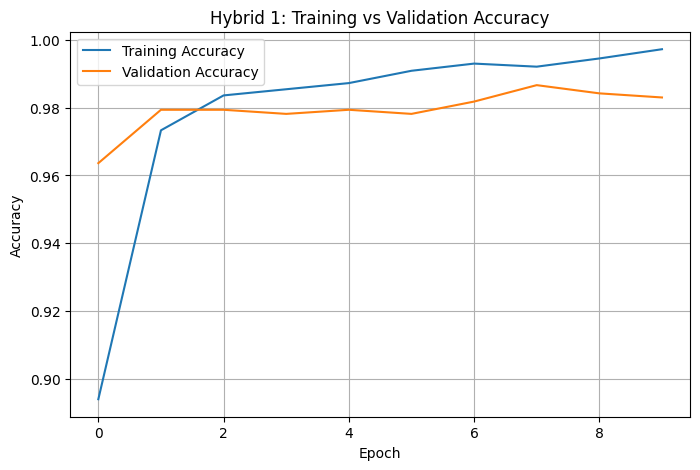

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_hybrid1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_hybrid1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Hybrid 1: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

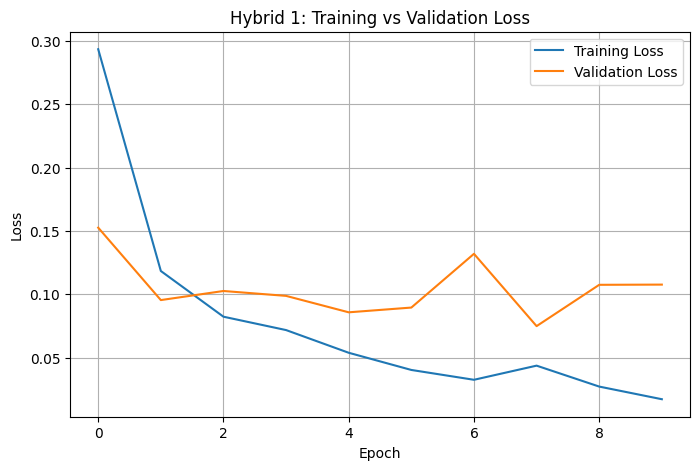

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_hybrid1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_hybrid1.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Hybrid 1: Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = hybrid1.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.1317
Test Accuracy: 97.38%


In [ ]:
start_time = time.time()

y_pred_probability = hybrid1.predict(
    X_test_padded,
    verbose=0
).flatten()

inference_time = time.time() - start_time

# Convert probabilities to classes
y_pred = (
    y_pred_probability >= 0.5
).astype(int)

print("Predictions generated.")

Predictions generated.


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9738
Accuracy: 97.38%


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Precision: {precision * 100:.2f}%")

Precision: 0.9316
Precision: 93.16%


In [ ]:
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Recall: {recall:.4f}")
print(f"Recall: {recall * 100:.2f}%")

Recall: 0.8516
Recall: 85.16%


In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"F1-score: {f1:.4f}")
print(f"F1-score: {f1 * 100:.2f}%")

F1-score: 0.8898
F1-score: 88.98%


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 896
False Positive: 8
False Negative: 19
True Positive : 109


<Figure size 700x600 with 0 Axes>

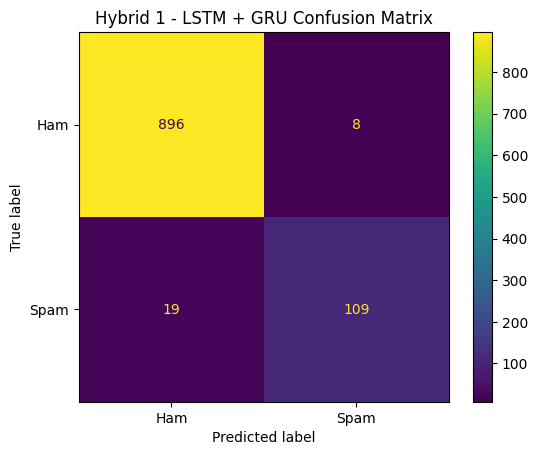

In [ ]:
plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title("Hybrid 1 - LSTM + GRU Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       904
        Spam       0.93      0.85      0.89       128

    accuracy                           0.97      1032
   macro avg       0.96      0.92      0.94      1032
weighted avg       0.97      0.97      0.97      1032



In [ ]:
specificity = tn / (tn + fp)

print(
    f"Specificity: {specificity:.4f}"
)

print(
    f"Specificity: {specificity * 100:.2f}%"
)

Specificity: 0.9912
Specificity: 99.12%


In [ ]:
fpr_value = fp / (fp + tn)

print(
    f"False Positive Rate: {fpr_value:.4f}"
)

print(
    f"False Positive Rate: {fpr_value * 100:.2f}%"
)

False Positive Rate: 0.0088
False Positive Rate: 0.88%


In [ ]:
fnr_value = fn / (fn + tp)

print(
    f"False Negative Rate: {fnr_value:.4f}"
)

print(
    f"False Negative Rate: {fnr_value * 100:.2f}%"
)

False Negative Rate: 0.1484
False Negative Rate: 14.84%


In [ ]:
macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")

Macro Precision: 0.9554
Macro Recall:    0.9214
Macro F1:        0.9375
Weighted F1:     0.9733


In [ ]:
roc_auc = roc_auc_score(
    y_test,
    y_pred_probability
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9730


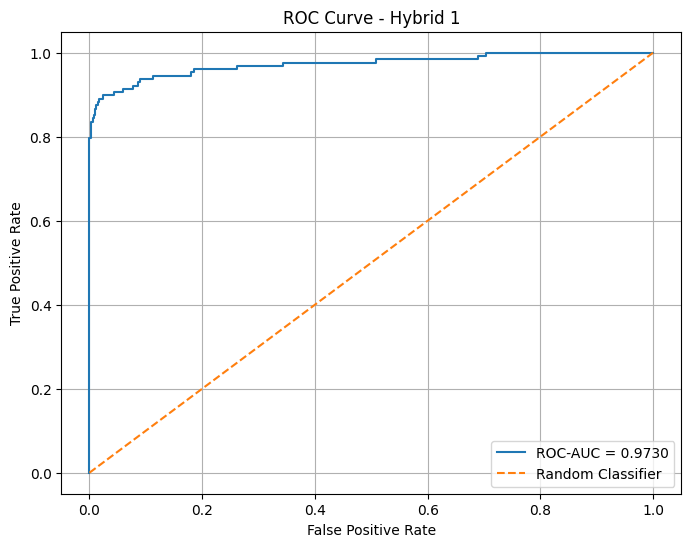

In [ ]:
fpr_curve, tpr_curve, thresholds = roc_curve(
    y_test,
    y_pred_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_curve,
    tpr_curve,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid 1")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_pred_probability
    )
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.9373


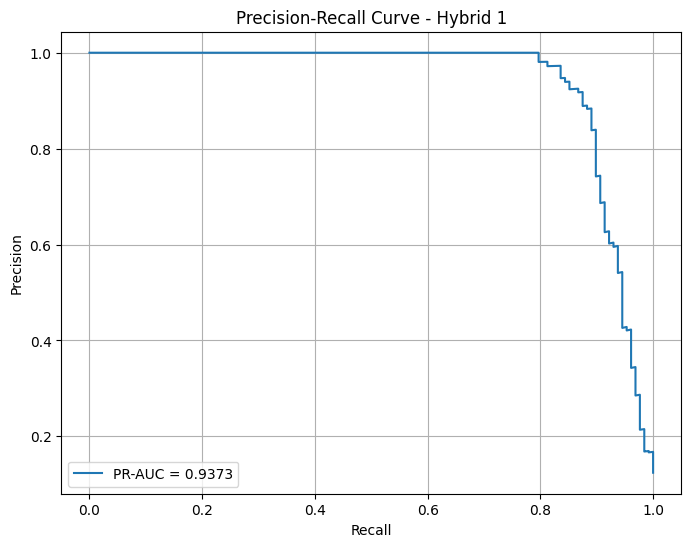

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Hybrid 1")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
mcc = matthews_corrcoef(
    y_test,
    y_pred
)

print(f"MCC: {mcc:.4f}")

MCC: 0.8761


In [ ]:
kappa = cohen_kappa_score(
    y_test,
    y_pred
)

print(f"Cohen's Kappa: {kappa:.4f}")

Cohen's Kappa: 0.8750


In [ ]:
logloss = log_loss(
    y_test,
    y_pred_probability
)

print(f"Log Loss: {logloss:.4f}")

Log Loss: 0.1317


In [ ]:
brier = brier_score_loss(
    y_test,
    y_pred_probability
)

print(f"Brier Score: {brier:.4f}")

Brier Score: 0.0256


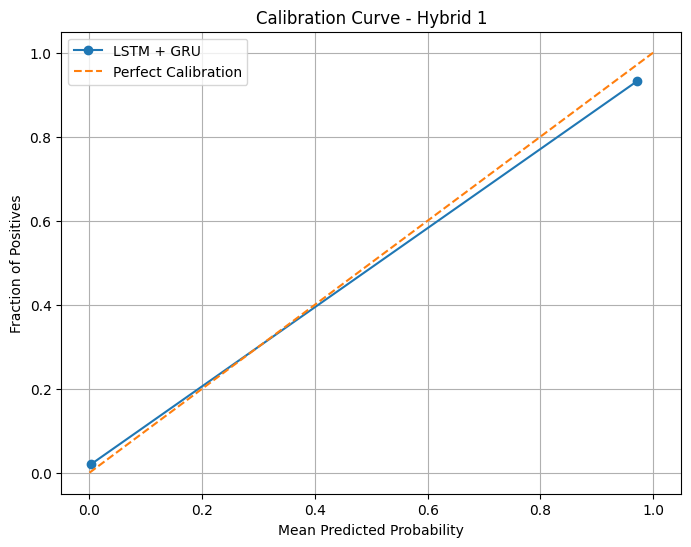

In [ ]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_pred_probability,
    n_bins=10
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="LSTM + GRU"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve - Hybrid 1")
plt.legend()
plt.grid(True)

plt.show()